In [8]:
# imported all required libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [9]:
#Using pandas, read the data into a variable called df and printed the output
df = pd.read_csv('/Users/ramithakotarkonda/CS598_FDC_Spring2025_Project/Curated Dataset/3_Deidentified/311_Service_Requests_K5_ANONYMIZED_GENERALIZED_20251022.csv')

print(df)

            SR_NUMBER                      SR_TYPE SR_SHORT_CODE  \
0       SR25-01948318     Aircraft Noise Complaint           AVN   
1       SR25-01948317   Street Light Out Complaint           SFD   
2       SR25-01948316     Aircraft Noise Complaint           AVN   
3       SR25-01948315    311 INFORMATION ONLY CALL        311IOC   
4       SR25-01948314     Aircraft Noise Complaint           AVN   
...               ...                          ...           ...   
193836  SR25-01702694  Dead Animal Pick-Up Request           SGQ   
193837  SR25-01702693     Aircraft Noise Complaint           AVN   
193838  SR25-01702692   Street Light Out Complaint           SFD   
193839  SR25-01702691   Street Light Out Complaint           SFD   
193840  SR25-01702690    311 INFORMATION ONLY CALL        311IOC   

                         CREATED_DEPARTMENT  \
0                                   Unknown   
1       CDOT - Department of Transportation   
2                                   Unknow

In [11]:
# select features that are required for the model

df_features = df[['SR_TYPE', 'OWNER_DEPARTMENT', 'STATUS', 'ORIGIN', 'LATITUDE', 'LONGITUDE', 'WARD', 'COMMUNITY_AREA']]
print(df_features)

                            SR_TYPE                     OWNER_DEPARTMENT  \
0          Aircraft Noise Complaint                             Aviation   
1        Street Light Out Complaint  CDOT - Department of Transportation   
2          Aircraft Noise Complaint                             Aviation   
3         311 INFORMATION ONLY CALL                    311 City Services   
4          Aircraft Noise Complaint                             Aviation   
...                             ...                                  ...   
193836  Dead Animal Pick-Up Request               Streets and Sanitation   
193837     Aircraft Noise Complaint                             Aviation   
193838   Street Light Out Complaint  CDOT - Department of Transportation   
193839   Street Light Out Complaint  CDOT - Department of Transportation   
193840    311 INFORMATION ONLY CALL                    311 City Services   

           STATUS      ORIGIN  LATITUDE  LONGITUDE  WARD  COMMUNITY_AREA  
0       Comp

In [13]:
# Dropping null values
df_features = df_features.dropna(subset=['LATITUDE', 'LONGITUDE'])
df_features.describe()

,LATITUDE,LONGITUDE,WARD,COMMUNITY_AREA
count,193695.000000,193695.000000,193660.000000,193660.000000
mean,41.893095,-87.726046,29.574600,41.129552
std,0.080168,0.093224,10.782191,23.601881
min,41.645000,-87.908000,1.000000,1.000000
25%,41.872000,-87.772000,28.000000,28.000000
50%,41.872000,-87.680000,28.000000,28.000000
75%,41.978000,-87.680000,41.000000,70.000000
max,42.023000,-87.525000,50.000000,77.000000


In [14]:
#encoding categorical variables because Kmeans algorithm doesn't use categorial variables
df_features = pd.get_dummies(df_features, columns=['SR_TYPE', 'OWNER_DEPARTMENT', 'STATUS', 'ORIGIN'], drop_first=True)
print(df_features)

        LATITUDE  LONGITUDE  WARD  COMMUNITY_AREA  \
1         41.770    -87.665  17.0            67.0   
7         41.794    -87.625  20.0            40.0   
11        41.910    -87.725  26.0            23.0   
12        41.919    -87.723  26.0            22.0   
13        41.925    -87.691   1.0            22.0   
...          ...        ...   ...             ...   
193836    41.768    -87.685  16.0            66.0   
193837    41.995    -87.888  41.0            76.0   
193838    41.911    -87.765  37.0            25.0   
193839    41.911    -87.767  29.0            25.0   
193840    41.872    -87.680  28.0            28.0   

        SR_TYPE_Abandoned Vehicle Complaint  SR_TYPE_Aircraft Noise Complaint  \
1                                         0                                 0   
7                                         0                                 0   
11                                        0                                 0   
12                                     

In [17]:
# Scale numeric variables
scaler = StandardScaler()
df_features[['LATITUDE', 'LONGITUDE', 'WARD', 'COMMUNITY_AREA']]= scaler.fit_transform(df_features[['LATITUDE', 'LONGITUDE', 'WARD', 'COMMUNITY_AREA']])

In [18]:
#Dimensionality Reduction

pca = PCA(n_components=10, random_state=42)
df_features = df_features.fillna(0)
X_pca = pca.fit_transform(df_features)

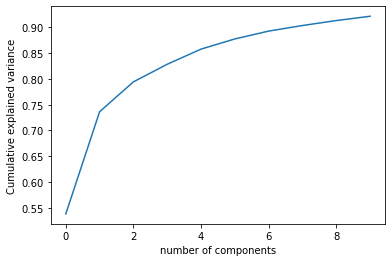

In [19]:
#PCA explained Variance
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('Cumulative explained variance')
plt.show()

In [20]:
#Dimensionality Reduction - using the chart to change the number of components to 3

pca = PCA(n_components=3, random_state=42)
df_features = df_features.fillna(0)
X_pca = pca.fit_transform(df_features)

In [21]:
#Kmeans clustering algorithm

kmeans = KMeans(n_clusters= 6, random_state=42)
# df_features['cluster'] = kmeans.fit_predict(X_pca)
# print(df_features)

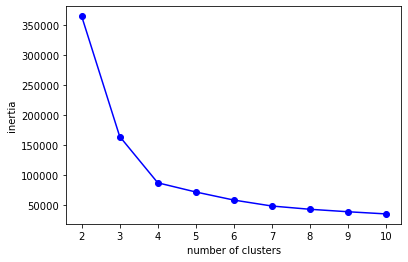

In [22]:
# finding the best number of clusters
intertias = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    intertias.append(kmeans.inertia_)

plt.plot(range(2,11), intertias, 'bo-')
plt.xlabel('number of clusters')
plt.ylabel('inertia')
plt.show()

In [23]:
#Kmeans clustering algorithm using the optimal number of clusters

kmeans = KMeans(n_clusters= 4, random_state=42)
df_features['cluster_actual'] = kmeans.fit_predict(X_pca)
print(df_features)

        LATITUDE  LONGITUDE      WARD  COMMUNITY_AREA  \
1      -1.535473   0.654835 -1.166241        1.096121   
7      -1.236100   1.083910 -0.888004       -0.047859   
11      0.210868   0.011224 -0.331529       -0.768142   
12      0.323133   0.032677 -0.331529       -0.810512   
13      0.397976   0.375937 -2.650173       -0.810512   
...          ...        ...       ...             ...   
193836 -1.560420   0.440298 -1.258987        1.053751   
193837  1.271147  -1.737255  1.059658        1.477447   
193838  0.223342  -0.417851  0.688674       -0.683403   
193839  0.223342  -0.439304 -0.053292       -0.683403   
193840 -0.263139   0.493932 -0.146037       -0.556294   

        SR_TYPE_Abandoned Vehicle Complaint  SR_TYPE_Aircraft Noise Complaint  \
1                                         0                                 0   
7                                         0                                 0   
11                                        0                             

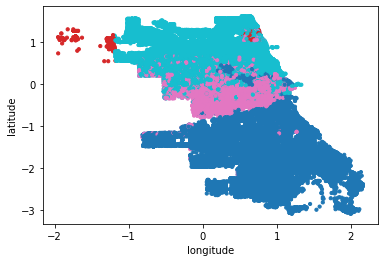

In [24]:
#visualizing the outputs
plt.scatter(df_features['LONGITUDE'], df_features['LATITUDE'], c=df_features['cluster_actual'], cmap='tab10', s=10)
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()

In [27]:
#total value counts for each cluster
info = df_features.groupby('cluster_actual').agg(lambda x: x.value_counts().index[0])
print(info)

                LATITUDE  LONGITUDE      WARD  COMMUNITY_AREA  \
cluster_actual                                                  
0              -1.061466   1.126817 -0.795258        0.333468   
1               1.271147  -1.737255  1.059658        1.477447   
2              -0.263139   0.493932 -0.146037       -0.556294   
3               0.585084   0.869373  1.245149       -1.488426   

                SR_TYPE_Abandoned Vehicle Complaint  \
cluster_actual                                        
0                                                 0   
1                                                 0   
2                                                 0   
3                                                 0   

                SR_TYPE_Aircraft Noise Complaint  \
cluster_actual                                     
0                                              0   
1                                              1   
2                                              0   
3                 

In [25]:
# average values for each cluster
info = df_features.groupby('cluster_actual').mean()
print(info)

                LATITUDE  LONGITUDE      WARD  COMMUNITY_AREA  \
cluster_actual                                                  
0              -1.500684   0.815087 -1.613692        0.573671   
1               1.268994  -1.717669  1.062985        1.477773   
2              -0.248853   0.471859 -0.163455       -0.563621   
3               0.653698   0.124564  0.829044       -1.121990   

                SR_TYPE_Abandoned Vehicle Complaint  \
cluster_actual                                        
0                                          0.072278   
1                                          0.001016   
2                                          0.005967   
3                                          0.074227   

                SR_TYPE_Aircraft Noise Complaint  \
cluster_actual                                     
0                                       0.000056   
1                                       0.986506   
2                                       0.000000   
3                 

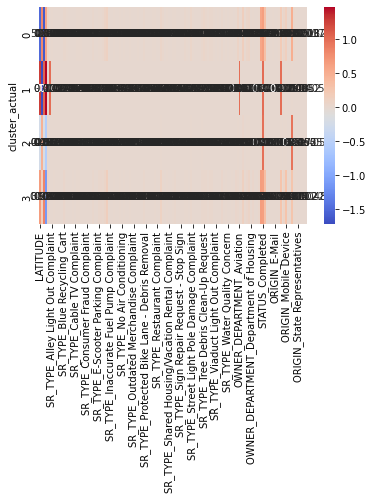

In [26]:
# visualizin the output of the means
sns.heatmap(info, annot=True, cmap='coolwarm')
plt.show()

Analysis

What does tell us about the dataset?


Cluster 0: More northern regions, aircraft noise issues (indicating the location is closer to airport), online requests;


Cluster 1: Middle regions, abandoned vehicle complaints, phone


Cluster 2: Southern regions, abandoned vehicle complaints, mix of mobile and phone


Cluster 3: middle regions, abandoned vehicle complaints, phone

What are potential recommendations?

Cluster 0: we can improve and expand upon the platforms where the online requests could be made. We can use these requests to collaborate with airports to help reduce determine the optimal flying time to mitigate the requests. 

Cluster 1: We can identify reasons why users prefer a phone complaint compared to an online or mobile request to reduce the amount of resources required for phone complaints. We can improve the phone call experience. 

Cluster 2: We can potentially create an app to enable users to file complaints more easily. 

Cluster 3: We can identify reasons why users prefer a phone complaint compared to an online or mobile request to reduce the amount of resources required for phone complaints. We can improve the phone call experience. 